# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

In [3]:
def plot_modified_df(df_cut):
    """
    Plots the modified DataFrame with adjusted time steps.

    Parameters:
    df_cut (pd.DataFrame): The modified DataFrame with adjusted time steps.

    Returns:
    None
    """
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'], label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'], label='Normal Force (Fz)', alpha=0.7)
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Modified Tangential vs Normal Force (Adjusted Timesteps)')
    plt.grid()
    plt.show()

<font size="6">Sediment 60°</font>

<font size="6">Test 1: (failed)</font>

Average Fx in the averaging interval [None:None]: 4.564351852671013
Average Fz in the averaging interval [None:None]: -2.5862548921558077
Maximum Fz in the plotting interval [None:None]: 1.1585489908854167 at timestep 766
Time step where Fx drops below 1: 0


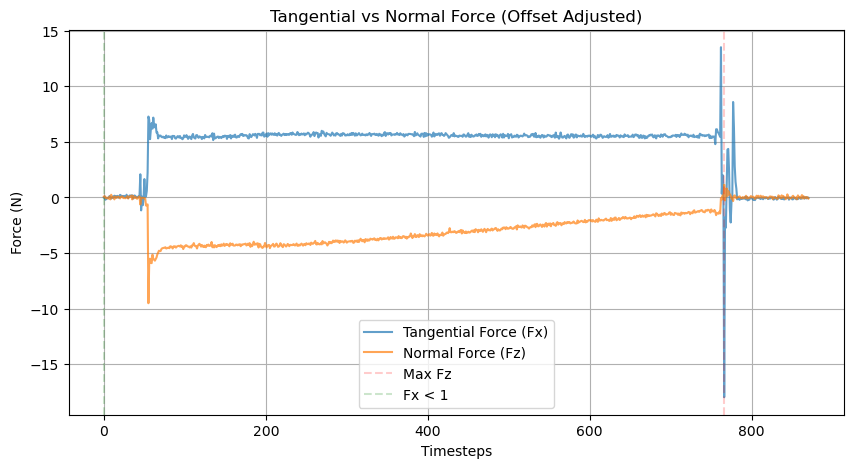

In [4]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_60_5N//log_202405241645.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 1087
Average Fx in the averaging interval [65:1152]: 5.6436449122845636
Average Fz in the averaging interval [65:1152]: 1.9514199086984438
Maximum Fz in the plotting interval [65:None]: 4.195638020833333 at timestep 1124
Time step where Fx drops below 1: 1152


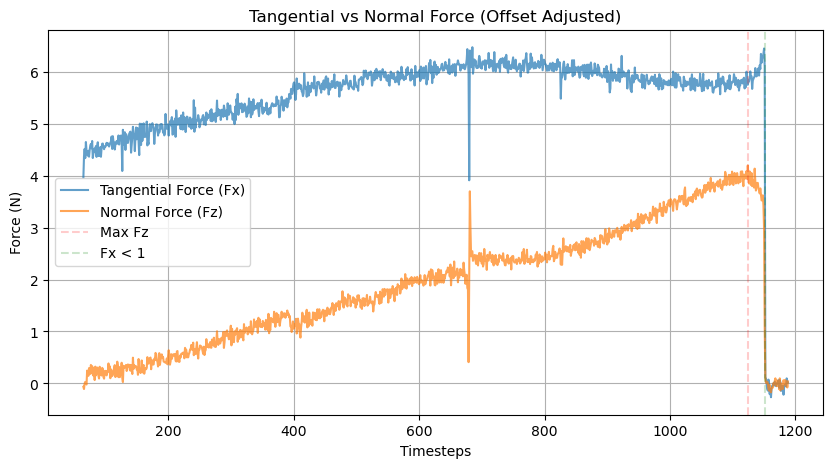

In [19]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_60_5N//log_202405241646.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=65, cut_2=None, avg_end=1152, offset_position='beginning', offset_length=15)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 931
Average Fx in the averaging interval [470:1401]: 6.014003161926488
Average Fz in the averaging interval [470:1401]: 1.5674242543440073
Maximum Fz in the plotting interval [470:None]: 3.147835286458333 at timestep 1363
Time step where Fx drops below 1: 1401


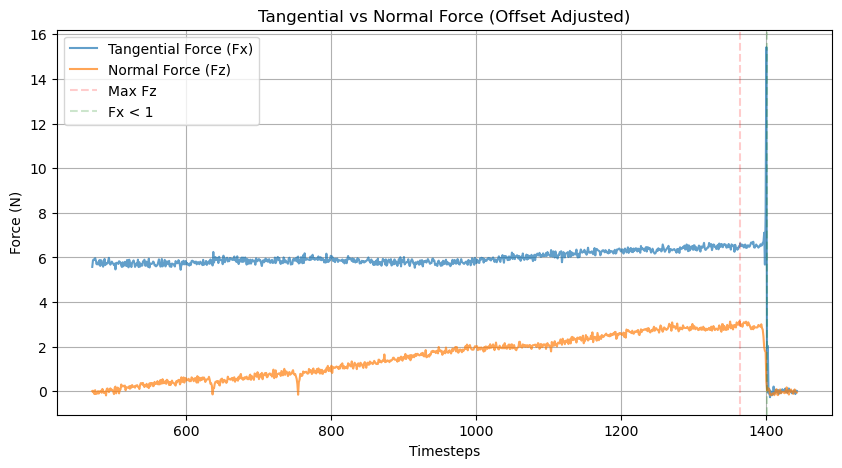

In [22]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_60_5N//log_202405241647.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=470, cut_2=None, avg_end=1401, offset_position='end', offset_length=15)

<font size="6">Test 4: (worked)</font>

Length from cut_1 to avg_end: 438
Average Fx in the averaging interval [170:608]: 5.792407874103007
Average Fz in the averaging interval [170:608]: 1.0101133581710189
Maximum Fz in the plotting interval [170:None]: 2.5920694986979167 at timestep 414
Time step where Fx drops below 1: 608


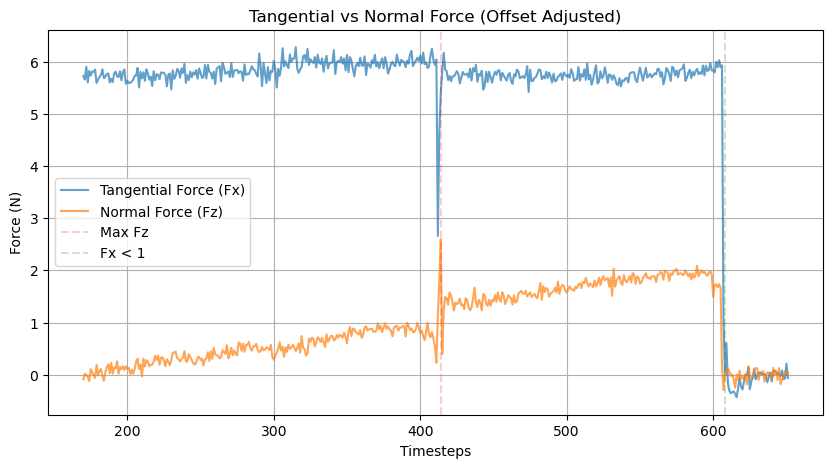

In [25]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_60_5N//log_202405241648.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=170, cut_2=None, avg_end=608, offset_position='end', offset_length=15)

<font size="6">Test 5: (worked)</font>

Length from cut_1 to avg_end: 239
Average Fx in the averaging interval [660:899]: 4.919656086633063
Average Fz in the averaging interval [660:899]: 0.3691500058566509
Maximum Fz in the plotting interval [660:None]: 0.9039469401041667 at timestep 851
Time step where Fx drops below 1: 899


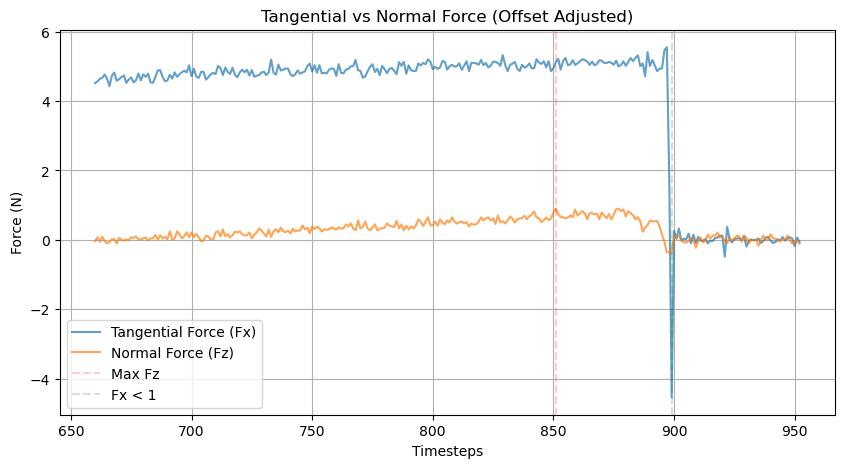

In [29]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_60_5N//log_202405241649.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=660, cut_2=None, avg_end=899, offset_position='end', offset_length=15)

<font size="6">Test 6a: (worked)</font>

Length from cut_1 to avg_end: 71
Average Fx in the averaging interval [500:571]: 5.412542851318216
Average Fz in the averaging interval [500:571]: 0.463887246002054
Maximum Fz in the plotting interval [500:590]: 1.0876871744791667 at timestep 548
Time step where Fx drops below 1: 571


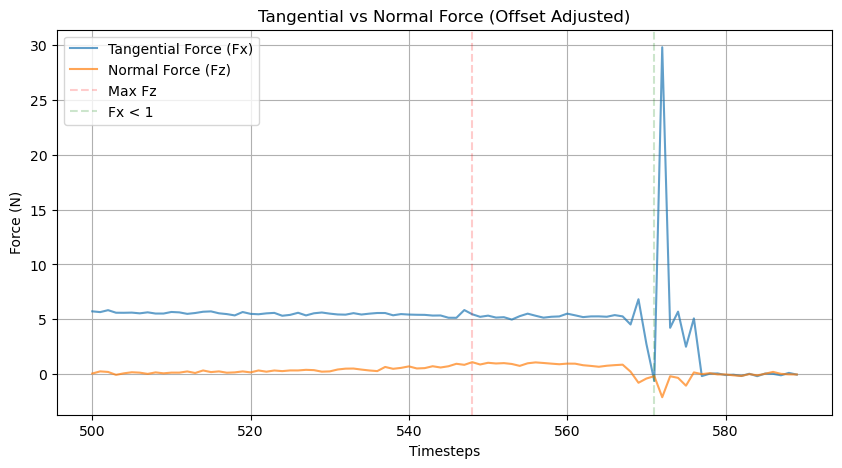

In [39]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_60_5N//log_202405241650.csv"
df = pd.read_csv(data)
test_6a, end_6a = plot_forces(df, cut_1=500, cut_2=590, avg_end=571, offset_position='beginning', offset_length=15)

<font size="6">Test 6b: (worked)</font>

Length from cut_1 to avg_end: 200
Average Fx in the averaging interval [980:1180]: 5.04791216770808
Average Fz in the averaging interval [980:1180]: 0.4363990275065104
Maximum Fz in the plotting interval [980:1200]: 1.0324503580729167 at timestep 1158
Time step where Fx drops below 1: 1180


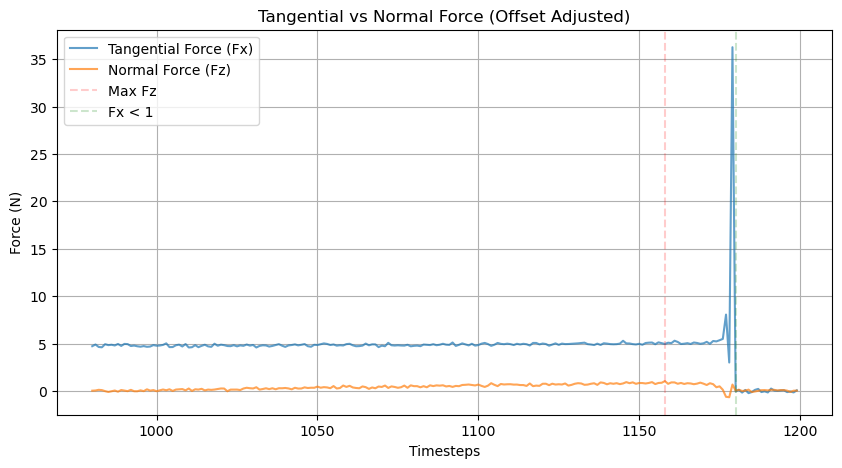

In [36]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_60_5N//log_202405241650.csv"
df = pd.read_csv(data)
test_6b, end_6b = plot_forces(df, cut_1=980, cut_2=1200, avg_end=1180, offset_position='beginning', offset_length=15)

<font size="6">Test 7: (worked)</font>

Length from cut_1 to avg_end: 568
Average Fx in the averaging interval [545:1113]: 5.7272625452364
Average Fz in the averaging interval [545:1113]: 1.116023387640295
Maximum Fz in the plotting interval [545:None]: 2.3962084960937498 at timestep 1070
Time step where Fx drops below 1: 1113


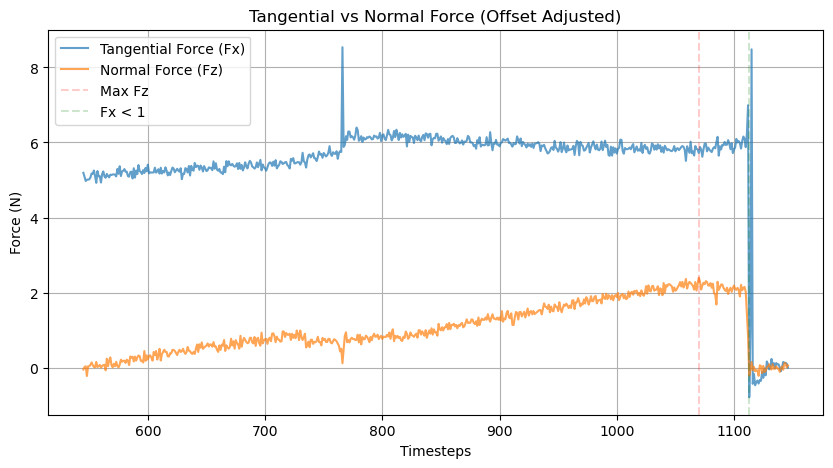

In [47]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_60_5N//log_202405241651.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=545, cut_2=None, avg_end=1113, offset_position='end', offset_length=25)

<font size="6">Test 8: (worked)</font>

Length from cut_1 to avg_end: 727
Average Fx in the averaging interval [360:1087]: 5.00593458588437
Average Fz in the averaging interval [360:1087]: 1.2115051185576426
Maximum Fz in the plotting interval [360:None]: 2.80670166015625 at timestep 1069
Time step where Fx drops below 1: 504


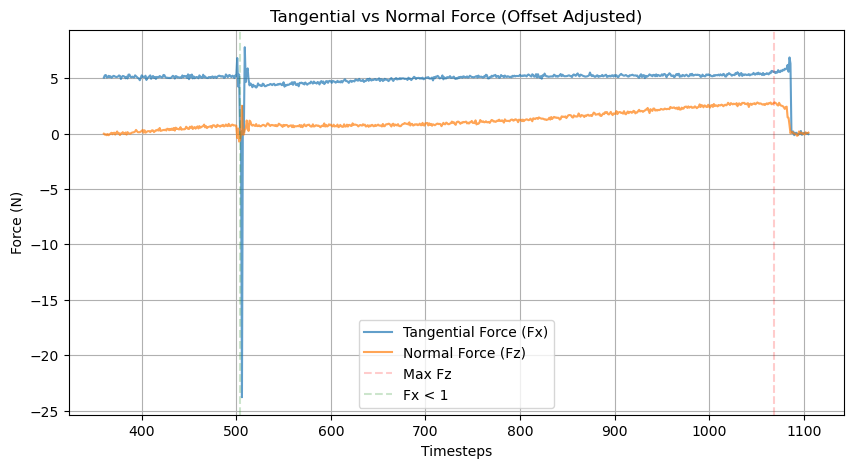

In [53]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_60_5N//log_202405241652.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=360, cut_2=None, avg_end=1087, offset_position='end', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 890
Average Fx in the averaging interval [71:961]: 5.96350178736426
Average Fz in the averaging interval [71:961]: 2.2089413532157067
Maximum Fz in the plotting interval [71:None]: 3.5187825520833336 at timestep 919
Time step where Fx drops below 1: 961


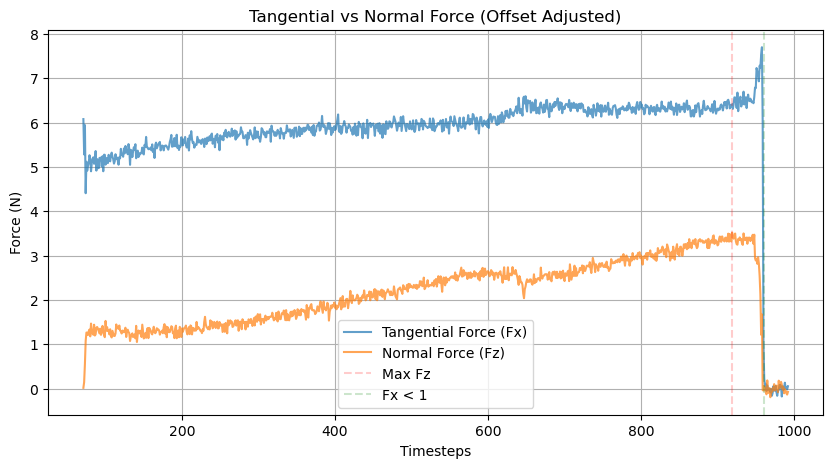

In [58]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_60_5N//log_202405241653.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=71, cut_2=None, avg_end=961, offset_position='end', offset_length=15)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 562
Average Fx in the averaging interval [1655:2217]: 6.040078398737336
Average Fz in the averaging interval [1655:2217]: 1.6674827494230984
Maximum Fz in the plotting interval [1655:None]: 2.9429931640625 at timestep 2123
Time step where Fx drops below 1: 2217


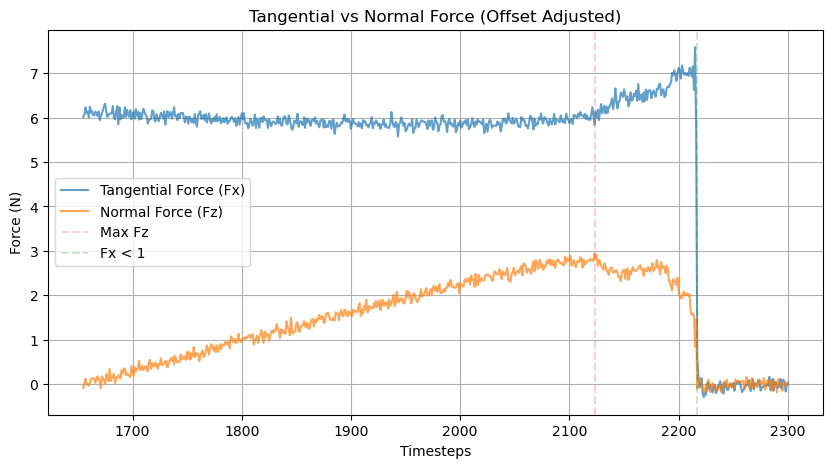

In [64]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_60_5N//log_202405241654.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=1655, cut_2=None, avg_end=2217, offset_position='end', offset_length=15)

In [65]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [71]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//60//Sediment_60_stats.csv", index=False)

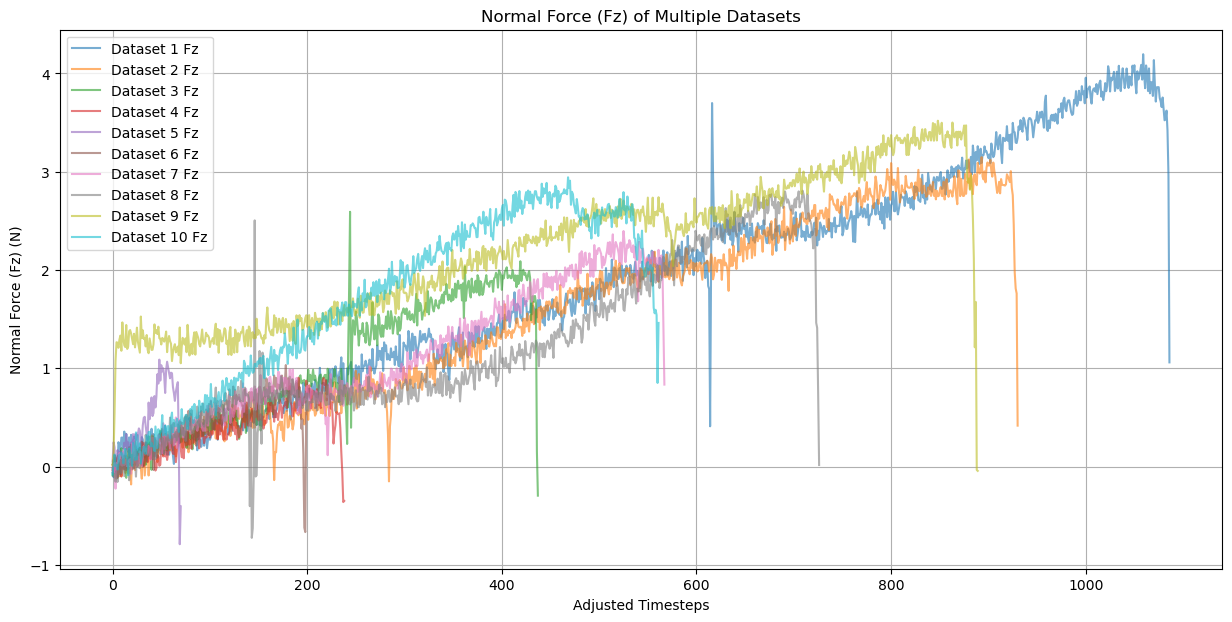

Average of maximum Fz forces: 2.4624313151041664
Standard deviation of maximum Fz forces: 1.0641407727802583
Average of average Fz forces: 1.2002346409415428
Standard deviation of average Fz forces: 0.6160061856039116
Average of average Fx forces: 5.556694437119578
Standard deviation of average Fx forces: 0.4110099249944194


In [72]:
tests = [test_2, test_3, test_4, test_5, test_6a, test_6b, test_7, test_8, test_9, test_10]
ends = [end_2, end_3, end_4, end_5, end_6a, end_6b, end_7, end_8, end_9, end_10]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [73]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//60//Sediment_60"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)